In [46]:
from typing import Any, Callable

import equinox as eqx
import jax
import jax.numpy as jnp
from spyx.axn import arctan
import matplotlib.pyplot as plt


_spike_fn = arctan(k=2)
class FeLIF(eqx.Module):
    out_size: int = eqx.field(static=True)
    P_s: float = eqx.field(static=True)  # max polarisation
    A: float = eqx.field(static=True)
    C_tot_init: float = eqx.field(static=True)
    step: Callable[[Any, Any], Any] = eqx.field(static=True)

    def __init__(
        self,
        out_size,
        A=25e-12,  # device area
        t_fe=9.8e-9,  # thikness ferroelectric
        eps_fe=70,  # ferroelectric dielectric constant
        eps_depl=3.6,  # interlayer dielectric constant
        q_fix_depl = 945e-4,
        n_depl = 1.4e28,
        e_off = 2e7,
        temp = 294,
        w_b = 1.05,
        d_e = 7.5e-9,
        P_s=27e-2,  # max polarisation
        I_0=1e-4,  # mult factor for leakage current
        V_t=0.32,  # normalization factor for voltage in leakage current
        C_par=15e-15,  # parasitic capacitance form the circuit
        soft_E=5e6,  # soft boudary for the electric field, avoid tau to diverge
        I_dsc=10e-12,  # discharge current, set the "dendritic time constant"
        V_thr=3.5,
        dt=1e-3,  # 1us timestep resolution
        innerStep=1000,
        paramsScale=1e12,  # Scale parameters to avoid underflow
        spike_fn=_spike_fn,
        stepFull=False,
        *,
        key=None
    ):
        _eps0 = 8.85418792394420013968e-12 * paramsScale
        _q = 1.60217663e-19 * paramsScale
        _k = 1.380649e-23 * paramsScale
        _h = 6.62607015e-34 * paramsScale

        self.out_size = out_size

        A = A * paramsScale
        t_fe = t_fe * paramsScale
        eps_fe = eps_fe
        eps_depl = eps_depl
        q_fix_depl = q_fix_depl
        n_depl = n_depl
        e_off = e_off
        temp = temp
        w_b = w_b
        d_e = d_e
        P_s = P_s
        I_0 = I_0
        V_t = V_t
        C_par = C_par * paramsScale
        soft_E = soft_E / paramsScale
        I_dsc = I_dsc * paramsScale
        V_thr = V_thr
        dt = dt
        innerStep = innerStep
        paramsScale = paramsScale

        # Initial values, to be checked whether sensible
        e_dummy = 0
        prob = 0
        
        C_fe = _eps0 * eps_fe / t_fe * A
        w_depl_d = ((_eps0 * eps_fe * e_dummy +  q_fix_depl) / _q / n_depl)
        w_depl_u = jnp.abs((_eps0 * eps_fe * e_dummy - q_fix_depl) / _q / n_depl)
        w_depl = (w_depl_d * w_depl_u / (prob * w_depl_u + (1 - prob) * w_depl_d))
        C_tot_init = 1/ (1/(C_fe + C_par) + 1/ (_eps0 * eps_depl / w_depl * A))
        # C_tot_init = 1/ (1/(C_fe + C_par))
        threshold = V_thr * C_tot_init + P_s * A

        #Save parameters in object
        self.A = A
        self.P_s = P_s
        self.C_tot_init = C_tot_init
        # print(w_depl_u)

        def updatePol(v, p, C_tot):

            # Until we find a better approximation or take the t-1 value
            e_dummy = v / t_fe

            def pol_step(state, input_):
                
                p, _, C_tot = state
                
                prob = p / 2 / P_s + 0.5
                w_depl_d = ((_eps0 * eps_fe * e_dummy +  q_fix_depl) / _q / n_depl)
                w_depl_u = jnp.abs((_eps0 * eps_fe * e_dummy - q_fix_depl) / _q / n_depl)
                w_depl = (w_depl_d * w_depl_u / (prob * w_depl_u + (1 - prob) * w_depl_d))
                C_tot = 1/ (1/(C_fe + C_par) + 1/ (_eps0 * eps_depl / w_depl * A))
                cap_divider = eps_depl / (t_fe * eps_depl + w_depl * eps_fe)
                depol_divider = 1 / _eps0 * w_depl / (t_fe * eps_depl + w_depl * eps_fe)

                E = v * cap_divider - p * depol_divider
                w_e = (E - e_off) * d_e
                k_plus =  _k * temp / _h * jnp.exp(-(w_b - w_e) * _q / _k / temp)
                dp = 2 * P_s * k_plus * (1 - prob) 
                I_p_new =  dp * A
                p = jnp.clip(p + 1e-3*dt * dp, -P_s, P_s)

                return (p, I_p_new, C_tot), None

            (p, I_p, C_tot), _ = jax.lax.scan(pol_step, (p, jnp.zeros_like(p), C_tot), jnp.arange(1000))

            return p, I_p, C_tot

        def step(state, input_):
            v, p, C_tot = state

            charge = v * C_tot + p * A
            spikes = spike_fn(charge - threshold)
            
            p_upper, I_p, C_tot = updatePol(v, p, C_tot)

            I_leak = (1e-4 * A * jnp.expm1(v / V_t) + I_dsc) * jnp.sign(v)
            dv = (input_ - I_leak - I_p) / C_tot

            v_upper = jnp.clip(v + dt * dv, 0, 5000)

            spikes_ref = jax.lax.stop_gradient(spikes)
            v_new = (1 - spikes_ref) * v_upper
            p_new = (1 - spikes_ref) * p_upper - (spikes_ref * P_s)

            return (v_new, p_new, C_tot), (v_new, p_new, spikes, C_tot)
        
        def step_full(state, input_):
            v, p, C_tot = state
            
            # Calculate spike
            threshold = V_thr * C_tot + P_s * self.A
            charge = v * C_tot + p * self.A
            spikes = spike_fn(charge - threshold)

            ### IEDM 2024
            e_dummy = v / t_fe
            prob = p / 2 / self.P_s + 0.5
            w_depl_d = ((_eps0 * eps_fe * e_dummy +  q_fix_depl) / _q / n_depl)
            w_depl_u = jnp.abs((_eps0 * eps_fe * e_dummy - q_fix_depl) / _q / n_depl)
            w_depl = (w_depl_d * w_depl_u / (prob * w_depl_u + (1 - prob) * w_depl_d))
            C_tot = 1/ (1/(C_fe + C_par) + 1/ (_eps0 * eps_depl / w_depl * self.A))
            # C_tot = 1/ (1/(C_fe + C_par))
            cap_divider = eps_depl / (t_fe * eps_depl + w_depl * eps_fe)
            depol_divider = 1 / _eps0 * w_depl / (t_fe * eps_depl + w_depl * eps_fe)

            E = v * cap_divider - p * depol_divider
            w_e = (E - e_off) * d_e
            k_plus =  _k * temp / _h * jnp.exp(-(w_b - w_e) * _q / _k / temp)
            dp = 2 * P_s * k_plus * (1 - prob) 
            I_p =  dp * A
            jax.debug.print("w_depl = {0}", w_depl)
            jax.debug.print("w_depl_d = {0}", w_depl_d)
            jax.debug.print("w_depl_u = {0}", w_depl_u)

            ### FeLIF
            I_leak = (1e-4 * A * jnp.expm1(v / V_t) + I_dsc) * jnp.sign(v)
            dv = (input_ - I_leak - I_p) / C_tot
        
            v_upper = jnp.clip(v + dt * dv, 0, 5)
            # p_upper = jnp.clip(p + dt * dp, -P_s, P_s)
            p_upper = p + dt * dp
            jax.debug.print("{0} = {1} + dt* {2} ", p_upper, p, dp)
            spikes_ref = jax.lax.stop_gradient(spikes)
            v_new = (1 - spikes_ref) * v_upper
            p_new = (1 - spikes_ref) * p_upper - (spikes_ref * P_s)

            return (v_new, p_new, C_tot), (v_new, p_new, spikes, E)

        if stepFull:
            self.step = jax.jit(step_full)
        else:
            self.step = jax.jit(step)

    @eqx.filter_jit
    def getCharge(self, v, p, c=C_tot_init):
        return v * c + p * self.A

    @jax.named_scope("nn.FeLIF")
    def __call__(self, input_):
        v0 = jnp.zeros((self.out_size,))
        p0 = jnp.zeros((self.out_size,)) - self.P_s
        C_tot = jnp.zeros((self.out_size,)) + self.C_tot_init
        # C_tot = self.C_tot_init

        state = (v0, p0, C_tot)
        _, out = jax.lax.scan(self.step, state, input_)
        v, p, s, c = out

        return s, self.getCharge(v, p, c), v, p, c
felif = FeLIF(1, spike_fn=_spike_fn, paramsScale=1, dt=1e-6, stepFull=True, key=None)

E_tot = [0.]
E_d = [-33605796.]
E_app = [0.]
[-0.26999983] = [-0.27] + dt* [0.00018604] 
E_tot = [3465975.5]
E_d = [-32899536.]
E_app = [3204218.2]
[-0.26999944] = [-0.26999983] + dt* [0.00038972] 
E_tot = [6233414.5]
E_d = [-32333808.]
E_app = [5770749.5]
[-0.26999873] = [-0.26999944] + dt* [0.00070467] 
E_tot = [8996377.]
E_d = [-31767370.]
E_app = [8340331.5]
[-0.26999745] = [-0.26999873] + dt* [0.00127504] 
E_tot = [11754428.]
E_d = [-31200296.]
E_app = [10912553.]
[-0.26999515] = [-0.26999745] + dt* [0.00230843] 
E_tot = [14506779.]
E_d = [-30632708.]
E_app = [13486668.]
[-0.26999098] = [-0.26999515] + dt* [0.00418104] 
E_tot = [17251998.]
E_d = [-30064830.]
E_app = [16061316.]
[-0.2699834] = [-0.26999098] + dt* [0.00757328] 
E_tot = [19987490.]
E_d = [-29497072.]
E_app = [18634024.]
[-0.2699697] = [-0.2699834] + dt* [0.01371022] 
E_tot = [22708578.]
E_d = [-28930196.]
E_app = [21200328.]
[-0.26994494] = [-0.2699697] + dt* [0.02477948] 
E_tot = [25406858.]
E_d = [-28365582.]
E_app

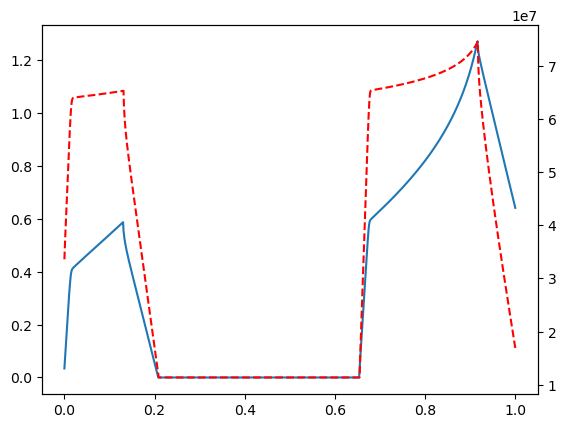

In [47]:
t = jnp.linspace(0, 1, 1000)
input = jnp.cos(8*t)
input = 50e-12*jnp.sign(input)*(input>0.5)
felif = FeLIF(1, spike_fn=_spike_fn, paramsScale=1, dt=1e-3, stepFull=True, key=None)
s, c, v, p, C_tot = felif(input)

plt.figure()
# plt.plot(t, input)
# plt.plot(t, p, 'r')
plt.plot(t, v)
ax=plt.gca().twinx()
# ax.plot(t, p, 'r')
# ax.plot(t, v, 'r--')
ax.plot(t, C_tot, 'r--')
plt.show()